# Visualize NWM



## Load model


In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "7"

In [2]:
import yaml
import torch
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
from PIL import Image
import requests
from io import BytesIO
import numpy as np
from IPython.display import display, HTML
import ipywidgets as widgets
from diffusers.models import AutoencoderKL

from diffusion import create_diffusion
from isolated_nwm_infer_v5 import model_forward_wrapper
from misc import transform
from models_tpz_v5 import CDiT_models
from datasets_v2 import TrainingDataset

EXP_NAME = 'nwm_cdit_airvln_airspace'
NAME = 'nwm_cdit_airvln_v5_0'
MODEL_PATH = f'logs/{NAME}/checkpoints/0200000.pth.tar'

with open("config/data_config.yaml", "r") as f:
    default_config = yaml.safe_load(f)
config = default_config

with open(f'config/{EXP_NAME}.yaml', "r") as f:
    user_config = yaml.safe_load(f)
config.update(user_config)
latent_size = config['image_size'] // 8

print("loading model")
model = CDiT_models[config['model']](input_size=latent_size, context_size=config['context_size'])
ckp = torch.load(MODEL_PATH, map_location='cpu', weights_only=False) 

print(model.load_state_dict(ckp["ema"], strict=True))
model.eval()
device = 'cuda:0'
model.to(device)
model = torch.compile(model)

diffusion = create_diffusion(str(250))
vae = AutoencoderKL.from_pretrained(f"stabilityai/sd-vae-ft-ema").to(device)
latent_size = config['image_size'] // 8



loading model
<All keys matched successfully>


## Choose starting image

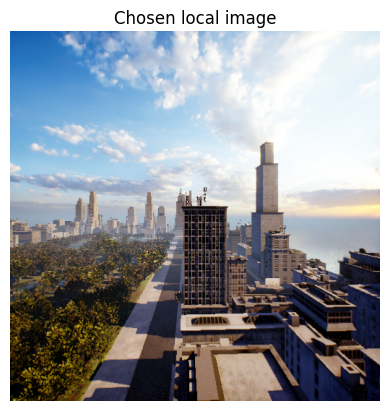

In [3]:
local_image_path = '/data1/tpz/nwm-main/data/airvln_airspace/30IQTZXKAT4SVRPVGO9446BX86EX0O_processed'
index = 16

def load_and_show_local_image(path):
    img = Image.open(path)
    import matplotlib.pyplot as plt
    plt.imshow(img)
    plt.axis('off')
    plt.title("Chosen local image")
    plt.show()
    from torchvision import transforms
    _transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5], inplace=True),
    ])
    
    x_start = _transform(img)
    return x_start.unsqueeze(0).expand(config['context_size'], x_start.shape[0], x_start.shape[1], x_start.shape[2])

x_start = load_and_show_local_image(local_image_path + f'/{index}.jpg')

In [4]:
import pickle
with open(os.path.join(local_image_path, "traj_data.pkl"), "rb") as f:
    traj_data = pickle.load(f)
for k,v in traj_data.items():
    traj_data[k] = v.astype('float')
K = traj_data["K"]
depth_map = traj_data["depth"][index]
print(K)

[[256.   0. 256.]
 [  0. 256. 256.]
 [  0.   0.   1.]]


## Visualize navigation commands

In [5]:
from project_functions import reproject_depth_to_other_pose, project_to_2d_image, resize_image_half
import cv2

def generate_augmented_image(K, depth_map, rgb_img, pose_src, pose_dst) -> np.ndarray:
    """
    基于深度图 + pose 生成从另一个相机视角观察到的图像。
    """
    dep_image_size = depth_map.shape  # (H, W)
    # print(dep_image_size)
    # print(rgb_img.shape)
    if rgb_img.shape[:2] != dep_image_size:
        H_rgb, W_rgb = rgb_img.shape[:2]
        depth_map = cv2.resize(depth_map, (W_rgb, H_rgb), interpolation=cv2.INTER_NEAREST)
    # print(depth_map.shape)
    points_3d, colors = reproject_depth_to_other_pose(K, depth_map, rgb_img, pose_src, pose_dst) 
    images = project_to_2d_image(K, points_3d, colors, depth_map.shape) # (H, W, 3)
    return images

def pose_vec_to_mat(pos):
    """
    Convert (x, y, z, yaw) to 4x4 transformation matrix
    """
    x, y, z, yaw = pos
    cos_yaw = np.cos(yaw)
    sin_yaw = np.sin(yaw)

    # Rotation around Z axis (yaw only)
    R = np.array([
        [cos_yaw, -sin_yaw, 0],
        [sin_yaw,  cos_yaw, 0],
        [0,        0,       1]
    ])

    t = np.array([[x], [y], [z]])

    T = np.eye(4)
    T[:3, :3] = R
    T[:3, 3:] = t

    return T

In [6]:
def update_position(last_pos, command):
    x, y, z, heading = last_pos
    if command == 'Forward':
        x += np.cos(heading)
        y += np.sin(heading)
    elif command == 'Back':
        x -= np.cos(heading)
        y -= np.sin(heading)
    elif command == 'Rotate Left':
        heading += 0.5 /(np.pi / 2)
    elif command == 'Rotate Right':
        heading -= 0.5 /(np.pi / 2)
    elif command == 'Up':
        z += 1
    elif command == 'Down':
        z -= 1
    heading = (heading + np.pi) % (2 * np.pi) - np.pi  # 保证在[-π, π]
    return (x, y, z, heading)

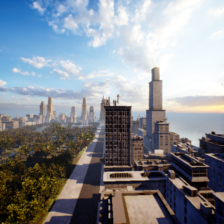

Output()

Button(description='Forward', style=ButtonStyle())

Button(description='Rotate Left', style=ButtonStyle())

Button(description='Rotate Right', style=ButtonStyle())

Button(description='Back', style=ButtonStyle())

Button(description='Up', style=ButtonStyle())

Button(description='Down', style=ButtonStyle())

Button(description='Reset', style=ButtonStyle())

In [7]:
commands = {
    'Forward': [1,0,0,0],
    'Rotate Right': [0,0,0,0.5],
    'Rotate Left': [0,0,0,-0.5],
    'Back': [-1,0,0,0],
    'Up': [0,0,-1,0],
    'Down': [0,0,1,0],
}# （dx, dy, dz, dθ）
trajectory = [(0.0, 0.0, 0.0, np.pi/2)]  # 初始位置和朝上方向（π/2）
preds = {}

def reset():
    x_cond_pixels = x_start
    reconstructed_image=x_cond_pixels.to(device)
    preds['x_cond_pixels_display'] = (reconstructed_image[-1] * 127.5 + 127.5).clamp(0, 255).permute(1, 2, 0).to("cpu", dtype=torch.uint8).numpy()
    preds['x_cond_pixels'] = x_cond_pixels
    preds['video'] = [preds['x_cond_pixels_display']]
    trajectory = [(0.0, 0.0, np.pi/2)]
    

reset()
display(Image.fromarray(preds['x_cond_pixels_display']))
Image.fromarray(preds['x_cond_pixels_display']).save('sacson.png')

output = widgets.Output()
display(output)
rel_t = (torch.ones(1)*0.0078125).to(device)

@output.capture()
def update_image(b):
    
    if b.description == 'Reset':
        print("Reset clicked!")
        output.clear_output(wait=False)
        reset()
        return

    print("Button clicked!")
    y = commands[b.description]
    y = torch.tensor(y).to(device).unsqueeze(0)
    
    print("You entered:", b.description)
    last_pos = trajectory[-1]
    new_pos = update_position(last_pos, b.description)
    trajectory.append(new_pos)
    print(f"Trajectory updated: {new_pos}")
    x_cond_pixels = preds['x_cond_pixels'][-4:].unsqueeze(0).to(device)
    last_pixels = preds['x_cond_pixels'][-1:].unsqueeze(0).to(device)
    rgb_img_tensor = preds['x_cond_pixels'][-1].cpu()  # 变成 [C, H, W]
    rgb_img_numpy = rgb_img_tensor.to(torch.float32).permute(1, 2, 0).numpy()  # 变成 [H, W, C]
    pose_src = pose_vec_to_mat(last_pos)
    pose_dst = pose_vec_to_mat(new_pos)
    x_supervised = generate_augmented_image(K=K, depth_map=depth_map, rgb_img=rgb_img_numpy, pose_src=pose_src, pose_dst=pose_dst)
    x_supervised = torch.from_numpy(x_supervised).permute(2, 0, 1).unsqueeze(0).unsqueeze(0).float().to(device) # [B, T, C, H, W]
    # print(x_cond_pixels.shape)
    # print(x_supervised.shape)
    samples = model_forward_wrapper((model, diffusion, vae), x_cond_pixels, y, None, latent_size, device, config["context_size"], num_goals=1, rel_t=rel_t, progress=True, x_supervised=x_supervised)
    x_cond_pixels = samples # torch.clip(samples, -1., 1.)
    preds['x_cond_pixels'] = torch.cat([preds['x_cond_pixels'].to(x_cond_pixels), x_cond_pixels], dim=0)
    samples = (samples * 127.5 + 127.5).permute(0, 2, 3, 1).clamp(0,255).to("cpu", dtype=torch.uint8).numpy()
    display(Image.fromarray(samples[0]))
    preds['video'].append(samples[0])

buttons = []
for o in ["Forward", "Rotate Left", "Rotate Right", "Back", "Up", "Down", "Reset"]:
    b = widgets.Button(description=o)
    b.on_click(update_image)
    display(b)
    buttons.append(b)

# Generate a video

In [8]:

# %matplotlib inline
# from matplotlib import pyplot as plt
# from matplotlib import animation
# from IPython.display import HTML
# import numpy as np
# # np array with shape (frames, height, width, channels)
# video = np.array(preds['video']) 

# fig = plt.figure()
# im = plt.imshow(video[0,:,:,:])

# plt.close() # this is required to not display the generated image

# def init():
#     im.set_data(video[0,:,:,:])

# def animate(i):
#     im.set_data(video[i,:,:,:])
#     return im

# anim = animation.FuncAnimation(fig, animate, init_func=init, frames=video.shape[0],
#                                interval=500)
# HTML(anim.to_html5_video())

In [14]:
print(trajectory)

[(0.0, 0.0, 0.0, 1.5707963267948966), (6.123233995736766e-17, 1.0, 0.0, 1.5707963267948966), (6.123233995736766e-17, 1.0, -1.0, 1.5707963267948966), (6.123233995736766e-17, 1.0, -2.0, 1.5707963267948966), (1.2246467991473532e-16, 2.0, -2.0, 1.5707963267948966), (1.8369701987210297e-16, 3.0, -2.0, 1.5707963267948966), (1.8369701987210297e-16, 3.0, -2.0, 1.889106212978687), (-0.3129617962077863, 3.949765715381639, -2.0, 1.889106212978687), (-0.3129617962077863, 3.949765715381639, -3.0, 1.889106212978687), (-0.3129617962077863, 3.949765715381639, -4.0, 1.889106212978687), (-0.3129617962077863, 3.949765715381639, -5.0, 1.889106212978687), (-0.3129617962077863, 3.949765715381639, -5.0, 1.5707963267948966), (-0.31296179620778625, 4.9497657153816395, -5.0, 1.5707963267948966), (-0.31296179620778625, 4.9497657153816395, -6.0, 1.5707963267948966), (-0.31296179620778625, 4.9497657153816395, -7.0, 1.5707963267948966), (-0.31296179620778625, 4.9497657153816395, -8.0, 1.5707963267948966), (-0.31296

In [15]:
%matplotlib inline
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import pyplot as plt
from matplotlib import animation
from IPython.display import HTML
from matplotlib import gridspec
import numpy as np

# 准备数据
video = np.array(preds['video'])  # [T, H, W, C]
positions = trajectory  # [(x, y, z, theta)]

xs = [p[0] for p in positions]
ys = [p[1] for p in positions]
zs = [p[2] for p in positions]
thetas = [p[3] for p in positions]

# 设置画布和子图
fig = plt.figure(figsize=(12, 6))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1.5])

# 左图：视频帧
ax1 = fig.add_subplot(gs[0])
im1 = ax1.imshow(video[0])
ax1.set_title("Video")
ax1.axis('off')

# 右图：3D轨迹
ax2 = fig.add_subplot(gs[1], projection='3d')
ax2.set_title("3D Trajectory with Heading")

margin = 1
ax2.set_xlim(min(xs) - margin, max(xs) + margin)
ax2.set_ylim(min(ys) - margin, max(ys) + margin)
ax2.set_zlim(min(zs) - margin, max(zs) + margin)

traj_line, = ax2.plot([], [], [], 'bo-', lw=2)

# 初始箭头
initial_x, initial_y, initial_z, initial_theta = positions[0]
initial_dx = np.cos(initial_theta)
initial_dy = np.sin(initial_theta)
initial_dz = 0

arrow = ax2.quiver(initial_x, initial_y, initial_z,
                   initial_dx, initial_dy, initial_dz,
                   length=1.0, normalize=True, color='red')

plt.close()

def init():
    im1.set_data(video[0])
    traj_line.set_data([], [])
    traj_line.set_3d_properties([])
    return im1, traj_line, arrow

def animate(i):
    global arrow

    # 更新视频帧
    im1.set_data(video[i])

    # 更新轨迹线
    traj_line.set_data(xs[:i+1], ys[:i+1])
    traj_line.set_3d_properties(zs[:i+1])

    # 更新箭头
    x, y, z, theta = positions[i]
    dx = np.cos(theta)
    dy = np.sin(theta)
    dz = 0  # 水平朝向

    try:
        arrow.remove()
    except Exception:
        pass

    arrow = ax2.quiver(x, y, z, dx, dy, dz,
                       length=1.0, normalize=True, color='red')

    return im1, traj_line, arrow

num_frames = min(len(video), len(positions))
anim = animation.FuncAnimation(fig, animate, init_func=init,
                               frames=num_frames, interval=500, blit=False)

HTML(anim.to_html5_video())


In [11]:
# optional: load from dataset
# dataloaders = {}

# for dataset_name in config["datasets"]:
#     data_config = config["datasets"][dataset_name]
#     for data_split_type in ["test"]: #["test"]:
#         dataset = TrainingDataset(
#             data_folder=data_config["data_folder"],
#             data_split_folder=data_config[data_split_type],
#             dataset_name=dataset_name,
#             image_size=config["image_size"],
#             min_dist_cat=config["distance"]["min_dist_cat"],
#             max_dist_cat=config["distance"]["max_dist_cat"],
#             len_traj_pred=config["len_traj_pred"],
#             context_size=config["context_size"],
#             normalize=config["normalize"],
#             goals_per_obs=1,
#             transform=transform,
#             predefined_index=None,
#             traj_stride=1,
#         )
#         dataloaders[f"{dataset_name}_{data_split_type}"] = dataset
#         print(f"Dataset: {dataset_name} ({data_split_type}), size: {len(dataset)}")

# load from dataset
# ds = dataloaders['recon_test'] # scand_test, 
# x, _, _ = ds[np.random.randint(len(ds))]
# x_start = x[:config["context_size"]]
